# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030


# Case Study: Why Aren't Maggie's Properties Selling?

Diagnosing why some of Maggie's real-estate listings have stayed unsold for more than 6 months.


## Likely root causes to investigate

1. **Overpricing vs. comparables** — price per sq. ft. compared to recently sold, similar
   properties in the same micro-location. Usually the #1 driver of long days-on-market (DOM).
2. **Location quality** — proximity to schools, transit, noise/industrial zones, crime rate
   in the neighborhood.
3. **Property condition / age** — deferred maintenance, outdated interiors, needed repairs.
4. **Marketing quality** — photo quality, listing description, virtual tour availability,
   portal syndication, agent responsiveness to inquiries.
5. **Segment-demand mismatch** — e.g., large single-family homes in a market where current
   buyer demand has shifted toward smaller/starter homes or condos.
6. **Macro / seasonal effects** — interest rate spikes, local job market slowdown, oversupply
   of similar inventory (high months-of-supply for that segment).

## A data-driven approach to isolate the actual cause

- **Segment the unsold properties with clustering** (K-Means) on features such as:
  `price_per_sqft_vs_area_median`, `days_on_market`, `condition_score`, `distance_to_transit`,
  `distance_to_school`, `listing_photo_count`. Properties that cluster together with high DOM
  usually share a common root cause — e.g., one cluster might be "well-located but overpriced",
  another "fairly priced but poor condition".
- **Regress DOM against these features** (linear regression or a tree-based model) to rank which
  factor most strongly predicts longer time-on-market for Maggie's portfolio specifically.
- **Compare marketing metrics** (listing views, inquiry rate) between fast-selling and slow-selling
  properties — low view/inquiry counts point to a marketing problem rather than a pricing or
  condition problem.

The template below shows how this analysis would run once real listing data is available
(columns are illustrative — replace the synthetic sample with Maggie's actual export).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

plt.rcParams['figure.figsize'] = (7, 5)


In [2]:
# ---- Replace this synthetic sample with Maggie's actual listings export ----
np.random.seed(42)
n = 150

df = pd.DataFrame({
    "price_per_sqft_vs_median": np.random.normal(0, 0.15, n),   # 0 = priced at market median
    "condition_score": np.random.uniform(1, 10, n),             # 10 = excellent condition
    "distance_to_transit_km": np.random.exponential(2, n),
    "listing_photo_count": np.random.randint(3, 25, n),
})

# Synthetic days-on-market driven mostly by overpricing and condition, for demonstration
df["days_on_market"] = (
    60
    + 250 * df["price_per_sqft_vs_median"].clip(lower=0)   # overpricing hurts a lot
    + (10 - df["condition_score"]) * 8
    + df["distance_to_transit_km"] * 5
    - df["listing_photo_count"] * 1.2
    + np.random.normal(0, 15, n)
).clip(lower=5)

df.head()


,price_per_sqft_vs_median,condition_score,distance_to_transit_km,listing_photo_count,days_on_market
0,0.074507,8.983778,0.938768,11,69.945659
1,-0.020740,8.018880,1.966250,6,60.512042
2,0.097153,6.778285,1.398879,24,117.727313
3,0.228454,1.757260,3.882699,19,180.197990
4,-0.035123,2.454658,2.149950,11,107.416598


In [3]:
# Cluster listings to find natural groupings of "why they're stuck"
features = ["price_per_sqft_vs_median", "condition_score", "distance_to_transit_km", "listing_photo_count"]
X_scaled = StandardScaler().fit_transform(df[features])

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

df.groupby("cluster")[features + ["days_on_market"]].mean().round(2)


,price_per_sqft_vs_median,condition_score,distance_to_transit_km,listing_photo_count,days_on_market
cluster,,,,,
0,0.03,5.84,1.70,20.11,98.22
1,-0.02,5.06,1.36,8.00,101.12
2,-0.11,5.97,6.31,10.15,117.08


In [4]:
# Rank which factor best predicts days-on-market
reg = LinearRegression().fit(df[features], df["days_on_market"])
importance = pd.Series(reg.coef_, index=features).sort_values(key=abs, ascending=False)
print("Estimated effect of each factor on days-on-market (holding others fixed):")
print(importance)


Estimated effect of each factor on days-on-market (holding others fixed):
price_per_sqft_vs_median    124.821767
condition_score              -7.788204
distance_to_transit_km        5.756571
listing_photo_count          -0.800612
dtype: float64


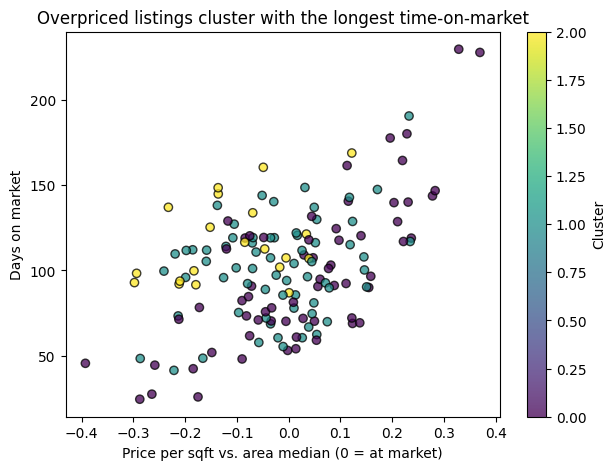

In [5]:
plt.scatter(df["price_per_sqft_vs_median"], df["days_on_market"],
            c=df["cluster"], cmap="viridis", edgecolor="k", alpha=0.75)
plt.xlabel("Price per sqft vs. area median (0 = at market)")
plt.ylabel("Days on market")
plt.title("Overpriced listings cluster with the longest time-on-market")
plt.colorbar(label="Cluster")
plt.show()
